# ENSD & CKA Representational Analysis of Virtual Rat Vision CNN

Computes the **Effective Number of Shared Dimensions (ENSD)** and **Centered Kernel Alignment (CKA)** between all pairs of layers in the vision CNN, reproducing Figure 3 from Giaffar et al. (AISTATS 2024).

**Reference:** Giaffar, Rullán Buxó & Aoi (2024). *The Effective Number of Shared Dimensions Between Paired Datasets.* AISTATS 2024, PMLR Vol. 238.

**Key questions:**
- Do we see dimensionality expansion then contraction across CNN layers (as in Figure 3A)?
- Is CKA relatively constant across layers (as in Figure 3B)?
- How does the virtual rat's visual processing compare to standard image classification CNNs?

**Architecture:**
```
vision (32×32×1) → CNN [4,8,16,32] → 32-dim features
[features, task_obs(54)] → Fusion MLP [256,256,256] → latent z (16-dim)
[z, proprioception] → Decoder MLP [512,512,512] → action params
```

## 1. Setup and Imports

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5"
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"

import json
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import orbax.checkpoint as ocp
from omegaconf import OmegaConf

from track_mjx.agent import checkpointing
from track_mjx.agent.checkpointing import _replace_zero_sized_arrays
from track_mjx.agent.ff_ppo import ppo_networks as ff_ppo_networks
from track_mjx.agent.ff_ppo.vision_encoder import VisionEncoder
from track_mjx.agent.ff_ppo.shared_vision_network import SharedVisionPolicyValueModule
from track_mjx.agent.observation_utils import (
    get_obs_sizes,
    init_dict_normalizer,
    normalize_dict_obs,
)
from vnl_playground import tasks
from vnl_playground.tasks.wrappers import HighLevelWrapper
from vnl_playground.tasks.rodent.vision_jax import JaxVisionRenderer
from mujoco.mjx.warp.types import DATA_NON_VMAP

print(f"JAX devices: {jax.devices()}")
print(f"JAX backend: {jax.default_backend()}")

JAX devices: [CudaDevice(id=0)]
JAX backend: gpu


## 2. Checkpoint Configuration

Toggle between monocular and binocular checkpoints by uncommenting the appropriate line.

In [28]:
CHECKPOINT_DIR = Path(
    "/home/talmolab/Desktop/SalkResearch/vnl-playground/"
    "highlvl_checkpoints/260215_091930"  # monocular
)
# CHECKPOINT_DIR = Path(
#     "/home/talmolab/Desktop/SalkResearch/vnl-playground/"
#     "highlvl_checkpoints/260221_115004"  # binocular
# )
MIMIC_CHECKPOINT_DIR = Path(
    "/home/talmolab/Desktop/SalkResearch/track-mjx/model_checkpoints"
)

EPISODE_LENGTH = 500
SEED = 50

## 3. Load Environment and Checkpoint

Load the checkpoint config, frozen decoder, environment, and restore the PPO network parameters.

In [3]:
# Load checkpoint config
with open(CHECKPOINT_DIR / "config.json") as f:
    cfg_dict = json.load(f)
cfg = OmegaConf.create(cfg_dict)

# Load frozen decoder
mimic_ckpt_path = str(MIMIC_CHECKPOINT_DIR / cfg.transfer.mimic_run_id)
mimic_cfg = OmegaConf.create(
    checkpointing.load_config_from_checkpoint(mimic_ckpt_path)
)
decoder_policy_fn = ff_ppo_networks.make_decoder_policy_fn(mimic_ckpt_path)
latent_size = mimic_cfg.network_config.intention_size

# Load environment (filter env_args to valid top-level keys)
env_args = (
    OmegaConf.to_container(cfg.env_config.get("env_args", {}), resolve=True) or {}
)
if hasattr(mimic_cfg, "env_config") and hasattr(mimic_cfg.env_config, "ctrl_dt"):
    env_args["ctrl_dt"] = float(mimic_cfg.env_config.ctrl_dt)

_VALID_OVERRIDE_KEYS = {
    "ctrl_dt", "sim_dt", "torque_actuators", "rescale_factor",
    "corridor_length", "corridor_width", "platform_length_range",
    "gap_length_range", "n_platforms", "episode_length", "action_repeat",
    "spawn_x", "randomize_gaps", "aesthetic",
    "vision_width", "vision_height", "grayscale", "vision_camera_name",
    "render_depth", "use_textures", "use_shadows",
    "naconmax", "njmax", "iterations", "ls_iterations", "noslip_iterations",
    "solver", "mujoco_impl",
}
filtered_env_args = {k: v for k, v in env_args.items() if k in _VALID_OVERRIDE_KEYS}
skipped = set(env_args.keys()) - set(filtered_env_args.keys())
if skipped:
    print(f"Skipping non-top-level env_args keys: {skipped}")

raw_env = tasks.load(
    cfg.env_config.env_name,
    flatten_obs=False,
    config_overrides=filtered_env_args if filtered_env_args else None,
)

# Get obs_sizes via HighLevelWrapper
highlvl_obs_key = cfg.transfer.get("highlvl_obs_key", "imitation_target")
decoder_obs_key = cfg.transfer.get("decoder_obs_key", "proprioception")
_tmp = HighLevelWrapper(
    raw_env,
    decoder_policy_fn,
    latent_size,
    highlvl_obs_key=highlvl_obs_key,
    decoder_obs_key=decoder_obs_key,
    pass_vision=True,
    pass_task_obs=True,
)
_tmp_state = _tmp.reset(jax.random.PRNGKey(99))
obs_sizes = get_obs_sizes(_tmp_state.obs)
del _tmp, _tmp_state

is_binocular = cfg.env_config.get("binocular", False)
print(f"Environment: {cfg.env_config.env_name}")
print(f"Binocular: {is_binocular}")
print(f"Latent size: {latent_size}")
print(f"Obs sizes: {obs_sizes}")

Skipping non-top-level env_args keys: {'termination_criteria', 'target_speed'}
Warp 1.12.0.dev20260222 initialized:
   Git commit: 46b17734a17b4663afc59b06f456f22fed81f23f
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/talmolab/.cache/warp/1.12.0.dev20260222
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 12773d5 load on device 'cuda:0' took 6.61 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 4d8b905 load on device 'cuda:0' took 0.30 ms  (cached)
Module _nxn_broadphase__locals__kernel_ad5e5280 ad5e528 load on device 'cuda:0' took 0.26 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_20ba1e98 

In [4]:
# Reconstruct PPO network
vision_shape = (
    cfg.env_config.get("vision_height", 32),
    cfg.env_config.get("vision_width", 32),
    1 if cfg.env_config.get("grayscale", True) else 3,
)

ppo_network, shared_module = (
    ff_ppo_networks.make_shared_vision_task_obs_highlvl_ppo_networks(
        obs_sizes=obs_sizes,
        action_size=latent_size,
        vision_shape=vision_shape,
        vision_latent_size=cfg.network_config.vision_latent_size,
        vision_feature_size=cfg.network_config.get("vision_feature_size", 32),
        decoder_hidden_layer_sizes=tuple(
            cfg.network_config.decoder_hidden_layer_sizes
        ),
        value_hidden_layer_sizes=tuple(
            cfg.network_config.value_hidden_layer_sizes
        ),
        vision_channels=tuple(cfg.network_config.vision_channels),
        fusion_hidden_layer_sizes=tuple(
            cfg.network_config.get("fusion_hidden_layer_sizes", [256])
        ),
    )
)

# Load checkpoint
ckpt_mgr = ocp.CheckpointManager(
    str(CHECKPOINT_DIR),
    options=ocp.CheckpointManagerOptions(
        save_interval_steps=1,
        max_to_keep=200,
        step_prefix="PPONetwork",
        create=False,
    ),
)
latest_step = ckpt_mgr.latest_step()

key_policy, _ = jax.random.split(jax.random.PRNGKey(0))
init_policy_params = ppo_network.policy_network.init(key_policy)
dummy_obs = {
    "imitation_target": jnp.zeros((1, obs_sizes["imitation_target"])),
    "proprioception": jnp.zeros((1, obs_sizes["proprioception"])),
}
abstract_policy = _replace_zero_sized_arrays(
    (init_dict_normalizer(dummy_obs), init_policy_params)
)
normalizer_params, policy_params = ckpt_mgr.restore(
    latest_step,
    args=ocp.args.Composite(policy=ocp.args.StandardRestore(abstract_policy)),
)["policy"]

print(f"Loaded checkpoint step {latest_step}")
print(f"Architecture: {cfg.network_config.arch_name}")
print(f"Vision shape: {vision_shape}")

Loaded checkpoint step 89
Architecture: shared_vision_task_obs
Vision shape: (32, 32, 1)


## 4. Param Tree Inspection

Verify the parameter structure so we know the exact key names for manual layer extraction.

In [5]:
def print_param_tree(params, prefix=""):
    if isinstance(params, dict):
        for k in sorted(params.keys()):
            print_param_tree(params[k], prefix=f"{prefix}/{k}")
    else:
        try:
            shape = params.shape
        except AttributeError:
            shape = f"(non-array: {type(params).__name__})"
        print(f"{prefix}: {shape}")


print("Policy params structure:")
print("-" * 60)
print_param_tree(policy_params["params"])

Policy params structure:
------------------------------------------------------------
/decoder/LayerNorm_0/bias: (512,)
/decoder/LayerNorm_0/scale: (512,)
/decoder/LayerNorm_1/bias: (512,)
/decoder/LayerNorm_1/scale: (512,)
/decoder/LayerNorm_2/bias: (512,)
/decoder/LayerNorm_2/scale: (512,)
/decoder/hidden_0/bias: (512,)
/decoder/hidden_0/kernel: (16, 512)
/decoder/hidden_1/bias: (512,)
/decoder/hidden_1/kernel: (512, 512)
/decoder/hidden_2/bias: (512,)
/decoder/hidden_2/kernel: (512, 512)
/decoder/hidden_3/bias: (32,)
/decoder/hidden_3/kernel: (512, 32)
/fusion_dense_0/bias: (256,)
/fusion_dense_0/kernel: (86, 256)
/fusion_dense_1/bias: (256,)
/fusion_dense_1/kernel: (256, 256)
/fusion_dense_2/bias: (256,)
/fusion_dense_2/kernel: (256, 256)
/fusion_norms_0/bias: (256,)
/fusion_norms_0/scale: (256,)
/fusion_norms_1/bias: (256,)
/fusion_norms_1/scale: (256,)
/fusion_norms_2/bias: (256,)
/fusion_norms_2/scale: (256,)
/fusion_out/bias: (16,)
/fusion_out/kernel: (256, 16)
/value_head/Laye

## 5. Layer Activation Extraction

Manual forward pass through every processing stage to capture intermediate representations.
Each layer's activations are flattened to 1D vectors for the ENSD/CKA analysis.

**Layers extracted:**
| Layer | Spatial | Channels | Flattened dims |
|-------|---------|----------|---------------|
| input | 32×32 | 1 | 1,024 |
| conv0 | 30×30 | 4 | 3,600 |
| conv1 | 28×28 | 8 | 6,272 |
| conv2 | 13×13 | 16 | 2,704 |
| conv3 | 6×6 | 32 | 1,152 |
| cnn_features | — | 32 | 32 |
| fusion0 | — | 256 | 256 |
| fusion1 | — | 256 | 256 |
| fusion2 | — | 256 | 256 |
| latent_z | — | 16 | 16 |

In [6]:
CHANNELS = tuple(cfg.network_config.vision_channels)
STRIDES = (1, 1, 2, 2)
N_FUSION_LAYERS = len(cfg.network_config.get("fusion_hidden_layer_sizes", [256]))


def extract_all_layer_activations(obs_b, normalizer_params, policy_params):
    """Extract activations at every processing stage of the monocular CNN policy.

    Performs a manual forward pass through the CNN, fc_project, fusion MLP,
    and fusion_out to capture intermediate representations.

    Args:
        obs_b: Raw observation dict (keys: vision, imitation_target, proprioception).
        normalizer_params: Running statistics for normalizing observations.
        policy_params: Policy parameter pytree.

    Returns:
        dict mapping layer_name -> 1-D numpy array (flattened activations).
    """
    activations = {}

    # Normalize observations
    obs_normed = normalize_dict_obs(obs_b, normalizer_params)

    # ── Input: raw normalized vision ──
    vision = obs_normed["vision"]
    activations["input"] = np.array(vision).flatten()

    # ── CNN conv layers (manual forward) ──
    cnn_params = policy_params["params"]["vision_encoder"]
    x = vision.reshape(1, 32, 32, 1)

    for i, (ch, stride) in enumerate(zip(CHANNELS, STRIDES)):
        kernel = cnn_params[f"conv_{i}"]["kernel"]
        bias = cnn_params[f"conv_{i}"]["bias"]
        x = (
            jax.lax.conv_general_dilated(
                x,
                kernel,
                window_strides=(stride, stride),
                padding="VALID",
                dimension_numbers=("NHWC", "HWIO", "NHWC"),
            )
            + bias
        )
        x = jax.nn.relu(x)
        activations[f"conv{i}"] = np.array(x[0]).flatten()

    # ── fc_project + LayerNorm + ReLU ──
    x_flat = x.reshape(1, -1)
    fc_w = cnn_params["fc_project"]["kernel"]
    fc_b = cnn_params["fc_project"]["bias"]
    feat = x_flat @ fc_w + fc_b

    ln_s = cnn_params["LayerNorm_0"]["scale"]
    ln_b = cnn_params["LayerNorm_0"]["bias"]
    mean = jnp.mean(feat, axis=-1, keepdims=True)
    var = jnp.var(feat, axis=-1, keepdims=True)
    feat = (feat - mean) / jnp.sqrt(var + 1e-5) * ln_s + ln_b
    feat = jax.nn.relu(feat)
    activations["cnn_features"] = np.array(feat[0])

    vision_feat = feat  # (1, 32)

    # ── Fusion MLP layers ──
    task_obs = obs_normed["imitation_target"]
    if task_obs.ndim == 1:
        task_obs = task_obs[None, :]

    combined = jnp.concatenate([vision_feat, task_obs], axis=-1)
    z = combined

    params = policy_params["params"]
    for i in range(N_FUSION_LAYERS):
        w = params[f"fusion_dense_{i}"]["kernel"]
        b = params[f"fusion_dense_{i}"]["bias"]
        z = z @ w + b
        z = jax.nn.silu(z)
        ln_s = params[f"fusion_norms_{i}"]["scale"]
        ln_b = params[f"fusion_norms_{i}"]["bias"]
        mean = jnp.mean(z, axis=-1, keepdims=True)
        var = jnp.var(z, axis=-1, keepdims=True)
        z = (z - mean) / jnp.sqrt(var + 1e-5) * ln_s + ln_b
        activations[f"fusion{i}"] = np.array(z[0])

    # ── Latent z ──
    w_out = params["fusion_out"]["kernel"]
    b_out = params["fusion_out"]["bias"]
    z = z @ w_out + b_out
    activations["latent_z"] = np.array(z[0])

    return activations

## 6. ENSD, PR, and CKA Metric Functions

Implementation of the three core metrics from Giaffar et al. (2024), Section 2:

- **Participation Ratio (PR):** $\gamma_X = \frac{\mathrm{trace}(XX^\top)^2}{\mathrm{trace}(XX^\top XX^\top)}$ — effective dimensionality of a single representation
- **ENSD:** $\nu_{X,Y} = \mathrm{trace}(G_X G_Y)$ — effective number of shared dimensions between two representations
- **CKA:** $\mathrm{CKA}(X,Y) = \frac{\nu_{X,Y}}{\sqrt{\gamma_X \gamma_Y}}$ — fraction of maximum possible shared dimensionality

In [7]:
def participation_ratio(X):
    """Participation ratio (effective dimensionality) of dataset X.

    Args:
        X: (n, p) data matrix. Will be mean-centered internally.

    Returns:
        γ_X = trace(XX^T)^2 / trace(XX^T XX^T)
    """
    X = X - X.mean(axis=0, keepdims=True)
    gram = X @ X.T
    trace_gram = np.trace(gram)
    trace_gram_sq = np.trace(gram @ gram)
    if trace_gram_sq == 0:
        return 0.0
    return trace_gram**2 / trace_gram_sq


def ensd(X, Y):
    """Effective Number of Shared Dimensions between X and Y.

    Args:
        X: (n, p) data matrix.
        Y: (n, q) data matrix. Must have same n (paired observations).

    Returns:
        ν_{X,Y} = trace(YY^T XX^T) * trace(XX^T) * trace(YY^T)
                  / (trace(XX^T XX^T) * trace(YY^T YY^T))
    """
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    XX = X @ X.T
    YY = Y @ Y.T
    trace_cross = np.trace(YY @ XX)
    trace_XX = np.trace(XX)
    trace_YY = np.trace(YY)
    trace_XXXX = np.trace(XX @ XX)
    trace_YYYY = np.trace(YY @ YY)
    denom = trace_XXXX * trace_YYYY
    if denom == 0:
        return 0.0
    return trace_cross * trace_XX * trace_YY / denom


def cka(X, Y):
    """Linear CKA (Centered Kernel Alignment) between X and Y.

    CKA = trace(XX^T YY^T) / sqrt(trace(XX^T XX^T) * trace(YY^T YY^T))
    Equivalently: CKA = ν_{X,Y} / sqrt(γ_X * γ_Y)

    Args:
        X: (n, p) data matrix.
        Y: (n, q) data matrix.

    Returns:
        CKA score in [0, 1].
    """
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    XX = X @ X.T
    YY = Y @ Y.T
    hsic_xy = np.trace(XX @ YY)
    hsic_xx = np.trace(XX @ XX)
    hsic_yy = np.trace(YY @ YY)
    denom = np.sqrt(hsic_xx * hsic_yy)
    if denom == 0:
        return 0.0
    return hsic_xy / denom

### Metric Validation

Quick sanity checks: ENSD(X,X) should equal PR(X), CKA(X,X) should be 1.0, and ENSD should respect its upper bound.

In [12]:
np.random.seed(42)
X_test = np.random.randn(100, 50)
Y_test = np.random.randn(100, 30)

pr_x = participation_ratio(X_test)
ensd_self = ensd(X_test, X_test)
cka_self = cka(X_test, X_test)
ensd_xy = ensd(X_test, Y_test)
cka_xy = cka(X_test, Y_test)
upper_bound = np.sqrt(pr_x * participation_ratio(Y_test))

print(f"PR(X) = {pr_x:.4f}")
print(f"ENSD(X, X) = {ensd_self:.4f}  (should equal PR)")
print(f"CKA(X, X) = {cka_self:.4f}  (should be 1.0)")
print(f"ENSD(X, Y) = {ensd_xy:.4f}")
print(f"Upper bound = {upper_bound:.4f}")
print(f"ENSD <= bound: {ensd_xy <= upper_bound + 1e-6}")
print(f"CKA = ENSD/sqrt(PR_x*PR_y): {np.isclose(cka_xy, ensd_xy / upper_bound)}")

PR(X) = 33.0013
ENSD(X, X) = 33.0013  (should equal PR)
CKA(X, X) = 1.0000  (should be 1.0)
ENSD(X, Y) = 8.2742
Upper bound = 27.8594
ENSD <= bound: True
CKA = ENSD/sqrt(PR_x*PR_y): True


## 7. Rollout with Layer Activation Recording

Run a full episode rollout, extracting all layer activations at every timestep. This produces
representation matrices of shape `(n_timesteps, n_features)` for each layer.

**Important:** Vision is rendered at each timestep using the `JaxVisionRenderer` (warp backend),
which produces real 32×32 egocentric grayscale images. Without this, the CNN receives
placeholder zeros and all layer activations collapse to rank-1.

In [29]:
# Warp batch-dim helper (renderer expects batched Data)
def _add_batch_dim_for_warp(data):
    """Add leading batch dim to Data, skipping non-vmap fields."""

    def _maybe_expand(path, x):
        parts = [p.name for p in path if hasattr(p, "name") and p.name != "_impl"]
        attr = "__".join(parts)
        if attr in DATA_NON_VMAP:
            return x
        return x[None, ...]

    return jax.tree.map_with_path(_maybe_expand, data)


# Vision renderer (warp backend — required for actual egocentric rendering)
vision_renderer = JaxVisionRenderer(
    mj_model=raw_env.mj_model,
    mjx_model=raw_env.mjx_model,
    nworld=1,
    width=cfg.env_config.get("vision_width", 32),
    height=cfg.env_config.get("vision_height", 32),
    grayscale=cfg.env_config.get("grayscale", True),
    camera_name=cfg.env_config.get("vision_camera_name", "egocentric-rodent"),
)

# HighLevelWrapper
eval_env = HighLevelWrapper(
    raw_env,
    decoder_policy_fn,
    latent_size,
    highlvl_obs_key=highlvl_obs_key,
    decoder_obs_key=decoder_obs_key,
    pass_vision=True,
    pass_task_obs=True,
)


# Wrap reset/step to render real vision at each timestep
def eval_reset(rng):
    state = eval_env.reset(rng)
    data_b = _add_batch_dim_for_warp(state.data)
    vision = vision_renderer.render(data_b)[0]
    return state.replace(obs={**state.obs, "vision": vision})


def eval_step(state, action):
    state = eval_env.step(state, action)
    data_b = _add_batch_dim_for_warp(state.data)
    vision = vision_renderer.render(data_b)[0]
    return state.replace(obs={**state.obs, "vision": vision})


# JIT compile
make_logging_policy = ff_ppo_networks.make_logging_inference_fn(ppo_network)
params_tuple = (normalizer_params, policy_params)
jit_inference_fn = jax.jit(make_logging_policy(deterministic=True))
jit_eval_reset = jax.jit(eval_reset)
jit_eval_step = jax.jit(eval_step)

print("Eval pipeline ready (with warp vision renderer).")

Eval pipeline ready (with warp vision renderer).


In [32]:
eval_rng = jax.random.PRNGKey(1)
state = jit_eval_reset(eval_rng)
act_rng = jax.random.PRNGKey(1 + 1)

# Collect activations and states across all timesteps
layer_trajectories = {}
rollout_states = []

print(f"Running rollout ({EPISODE_LENGTH} steps)...")
for t in range(EPISODE_LENGTH + 1):
    acts = extract_all_layer_activations(
        state.obs, normalizer_params, policy_params
    )
    for name, vec in acts.items():
        if name not in layer_trajectories:
            layer_trajectories[name] = []
        layer_trajectories[name].append(vec)

    rollout_states.append(state)

    if t < EPISODE_LENGTH:
        _, act_rng = jax.random.split(act_rng)
        action, _ = jit_inference_fn(params_tuple, state.obs, act_rng)
        state = jit_eval_step(state, action)

    if (t + 1) % 100 == 0:
        print(f"  Step {t + 1}/{EPISODE_LENGTH}")

# Stack into (n_timesteps, n_features) matrices
layer_matrices = {name: np.array(traj) for name, traj in layer_trajectories.items()}

print("\nLayer representation matrices:")
for name, mat in layer_matrices.items():
    print(f"  {name}: {mat.shape}")

Running rollout (500 steps)...
  Step 100/500
  Step 200/500
  Step 300/500
  Step 400/500
  Step 500/500

Layer representation matrices:
  input: (501, 1024)
  conv0: (501, 3600)
  conv1: (501, 6272)
  conv2: (501, 2704)
  conv3: (501, 1152)
  cnn_features: (501, 32)
  fusion0: (501, 256)
  fusion1: (501, 256)
  fusion2: (501, 256)
  latent_z: (501, 16)


In [33]:
import gc
import imageio
import mujoco

video_path = str(CHECKPOINT_DIR.parent / "ensd_rollout.mp4")
fps = int(1.0 / raw_env.dt)

# ── Batch-render egocentric vision on GPU via jax.lax.scan ──
print("Batch-rendering egocentric vision frames on GPU...")
all_data = jax.tree.map(
    lambda *xs: jnp.stack(xs), *[s.data for s in rollout_states]
)

@jax.jit
def _render_all_ego(stacked_data):
    def body(carry, data_slice):
        batched = _add_batch_dim_for_warp(data_slice)
        img = vision_renderer.render(batched)
        return carry, img[0]
    _, all_imgs = jax.lax.scan(body, None, stacked_data)
    return all_imgs

ego_imgs = np.array(_render_all_ego(all_data))
del all_data
gc.collect()

# Prepare overlay: grayscale -> RGB, float32 -> uint8, 2x upscale
if ego_imgs.shape[-1] == 1:
    ego_imgs = np.repeat(ego_imgs, 3, axis=-1)
ego_overlay = np.clip(ego_imgs * 255, 0, 255).astype(np.uint8)
ego_overlay = np.repeat(np.repeat(ego_overlay, 2, axis=1), 2, axis=2)
del ego_imgs
gc.collect()
print(f"  Ego overlay shape: {ego_overlay.shape}")

# ── Render main camera with tracking + ego overlay ──
mj_data = mujoco.MjData(raw_env.mj_model)
renderer = mujoco.Renderer(raw_env.mj_model, height=480, width=640)

camera = mujoco.MjvCamera()
camera.type = mujoco.mjtCamera.mjCAMERA_TRACKING
for name in ["torso-rodent", "torso", "torso_link"]:
    try:
        camera.trackbodyid = raw_env.mj_model.body(name).id
        break
    except Exception:
        continue
camera.distance = 1.0
camera.azimuth = 90
camera.elevation = -20
camera.lookat[:] = [0, 0, 0.3]

print(f"Rendering {len(rollout_states)} frames at {fps} fps...")
with imageio.get_writer(video_path, fps=fps) as writer:
    for i, state in enumerate(rollout_states):
        mj_data.qpos = np.array(state.data.qpos)
        mujoco.mj_forward(raw_env.mj_model, mj_data)
        renderer.update_scene(mj_data, camera)
        frame = renderer.render()

        # Composite ego overlay in upper-left corner with white border
        ego = ego_overlay[i]
        sh, sw = ego.shape[:2]
        pad = 2
        y0, x0 = pad + 4, pad + 4
        y1, x1 = y0 + sh, x0 + sw
        if y1 + pad < frame.shape[0] and x1 + pad < frame.shape[1]:
            frame[y0 - pad : y1 + pad, x0 - pad : x1 + pad] = 255
            frame[y0:y1, x0:x1] = ego

        writer.append_data(frame)

renderer.close()
del ego_overlay
gc.collect()
print(f"Saved: {video_path} ({len(rollout_states)} frames, {len(rollout_states)/fps:.1f}s)")

Batch-rendering egocentric vision frames on GPU...
  Ego overlay shape: (501, 64, 64, 3)
Rendering 501 frames at 100 fps...


/usr/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


Saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/ensd_rollout.mp4 (501 frames, 5.0s)


## 8. Pairwise ENSD and CKA Computation

Compute the ENSD and CKA between all pairs of layers, plus the Participation Ratio (PR) for each layer.

In [34]:
analysis_layers = [
    "conv0", "conv1", "conv2", "conv3", "cnn_features",
    "fusion0", "fusion1", "fusion2", "latent_z",
]
analysis_layers = [l for l in analysis_layers if l in layer_matrices]
n_layers = len(analysis_layers)

# PR per layer
pr_values = {}
for name in analysis_layers:
    pr_values[name] = participation_ratio(layer_matrices[name])
    print(f"PR({name}): {pr_values[name]:.2f}  (dims: {layer_matrices[name].shape[1]})")

# Pairwise ENSD
ensd_matrix = np.zeros((n_layers, n_layers))
for i, l1 in enumerate(analysis_layers):
    for j, l2 in enumerate(analysis_layers):
        if i == j:
            ensd_matrix[i, j] = pr_values[l1]
        elif j > i:
            val = ensd(layer_matrices[l1], layer_matrices[l2])
            ensd_matrix[i, j] = val
            ensd_matrix[j, i] = val

# Pairwise CKA
cka_matrix = np.zeros((n_layers, n_layers))
for i, l1 in enumerate(analysis_layers):
    for j, l2 in enumerate(analysis_layers):
        if i == j:
            cka_matrix[i, j] = 1.0
        elif j > i:
            val = cka(layer_matrices[l1], layer_matrices[l2])
            cka_matrix[i, j] = val
            cka_matrix[j, i] = val

print(f"\nENSD range: [{ensd_matrix.min():.2f}, {ensd_matrix.max():.2f}]")
print(f"CKA range: [{cka_matrix.min():.4f}, {cka_matrix.max():.4f}]")

PR(conv0): 7.75  (dims: 3600)
PR(conv1): 44.26  (dims: 6272)
PR(conv2): 36.54  (dims: 2704)
PR(conv3): 22.49  (dims: 1152)
PR(cnn_features): 7.30  (dims: 32)
PR(fusion0): 29.71  (dims: 256)
PR(fusion1): 30.69  (dims: 256)
PR(fusion2): 24.17  (dims: 256)
PR(latent_z): 10.36  (dims: 16)

ENSD range: [2.39, 44.26]
CKA range: [0.1850, 1.0000]


## 9. Figure 3 Reproduction — ENSD and CKA Heatmaps

**Figure 3A** (Giaffar et al.): Layer × layer ENSD heatmap with PR on the diagonal.
The diagonal values show the effective dimensionality of each layer — we expect
to see expansion (increasing PR) in early conv layers followed by contraction.

**Figure 3B**: Layer × layer CKA heatmap. CKA is the fraction of maximum possible
shared dimensionality. The paper found CKA remains relatively constant across layers.

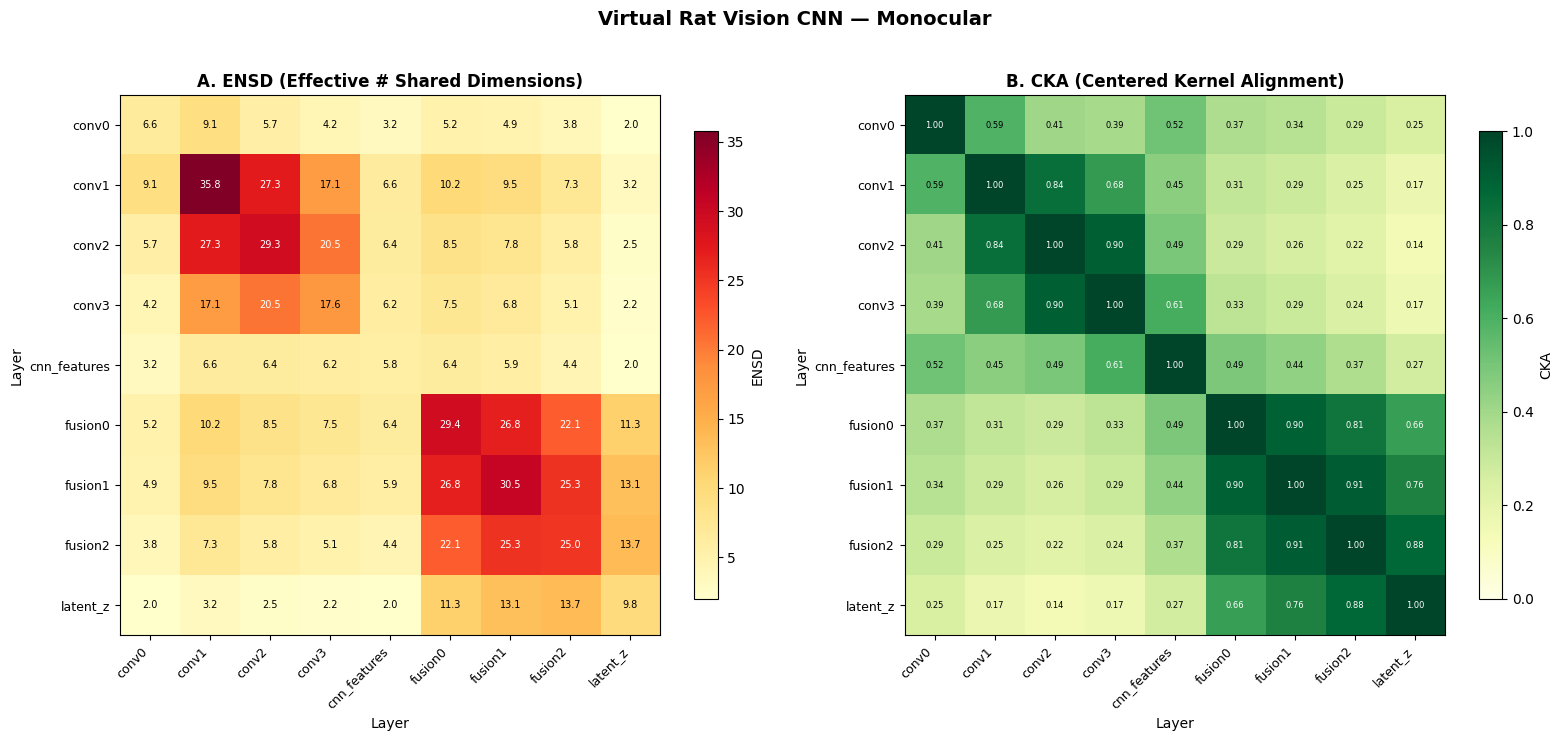

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── ENSD heatmap ──
ax = axes[0]
im1 = ax.imshow(ensd_matrix, cmap="YlOrRd", origin="upper")
ax.set_xticks(range(n_layers))
ax.set_xticklabels(analysis_layers, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(n_layers))
ax.set_yticklabels(analysis_layers, fontsize=9)
ax.set_title("A. ENSD (Effective # Shared Dimensions)", fontsize=12, fontweight="bold")
ax.set_xlabel("Layer")
ax.set_ylabel("Layer")
cbar1 = plt.colorbar(im1, ax=ax, shrink=0.8)
cbar1.set_label("ENSD")

for i in range(n_layers):
    for j in range(n_layers):
        color = "white" if ensd_matrix[i, j] > ensd_matrix.max() * 0.5 else "black"
        ax.text(
            j, i, f"{ensd_matrix[i, j]:.1f}",
            ha="center", va="center", fontsize=7, color=color,
        )

# ── CKA heatmap ──
ax = axes[1]
im2 = ax.imshow(cka_matrix, cmap="YlGn", vmin=0, vmax=1, origin="upper")
ax.set_xticks(range(n_layers))
ax.set_xticklabels(analysis_layers, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(n_layers))
ax.set_yticklabels(analysis_layers, fontsize=9)
ax.set_title("B. CKA (Centered Kernel Alignment)", fontsize=12, fontweight="bold")
ax.set_xlabel("Layer")
ax.set_ylabel("Layer")
cbar2 = plt.colorbar(im2, ax=ax, shrink=0.8)
cbar2.set_label("CKA")

for i in range(n_layers):
    for j in range(n_layers):
        color = "white" if cka_matrix[i, j] > 0.6 else "black"
        ax.text(
            j, i, f"{cka_matrix[i, j]:.2f}",
            ha="center", va="center", fontsize=6, color=color,
        )

model_label = "Binocular" if is_binocular else "Monocular"
fig.suptitle(
    f"Virtual Rat Vision CNN — {model_label}",
    fontsize=14, fontweight="bold", y=1.02,
)
fig.tight_layout()
plt.savefig(
    str(CHECKPOINT_DIR.parent / "ensd_cka_heatmaps.png"),
    dpi=150, bbox_inches="tight",
)
plt.show()

## 10. PR per Layer and Adjacent Layer Summary

**Left:** Participation Ratio (effective dimensionality) at each layer. This is the diagonal
of the ENSD heatmap. The paper showed an initial expansion (PR increases) followed by
contraction (PR decreases) toward the output.

**Right:** For each pair of adjacent layers, we plot the ENSD, its upper bound $\sqrt{\gamma_X \gamma_Y}$,
and the CKA. This directly corresponds to Figure 3C in the paper.

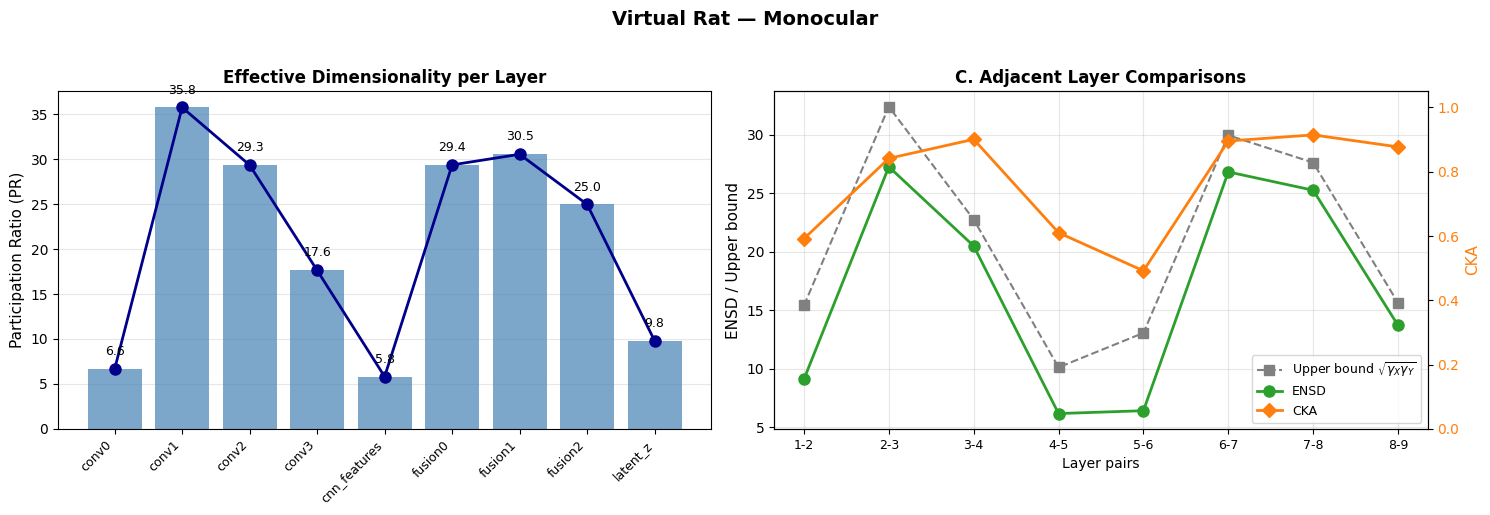

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ── PR per layer ──
pr_vals = [pr_values[l] for l in analysis_layers]
ax1.bar(range(n_layers), pr_vals, color="steelblue", alpha=0.7, zorder=2)
ax1.plot(range(n_layers), pr_vals, "o-", color="darkblue", linewidth=2, markersize=8, zorder=3)
ax1.set_xticks(range(n_layers))
ax1.set_xticklabels(analysis_layers, rotation=45, ha="right", fontsize=9)
ax1.set_ylabel("Participation Ratio (PR)", fontsize=11)
ax1.set_title("Effective Dimensionality per Layer", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3, axis="y")
for i, v in enumerate(pr_vals):
    ax1.annotate(
        f"{v:.1f}", (i, v),
        textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9,
    )

# ── Adjacent layer pairs ──
adj_ensd = [ensd_matrix[i, i + 1] for i in range(n_layers - 1)]
adj_upper = [
    np.sqrt(pr_values[analysis_layers[i]] * pr_values[analysis_layers[i + 1]])
    for i in range(n_layers - 1)
]
adj_cka = [cka_matrix[i, i + 1] for i in range(n_layers - 1)]
pair_labels = [f"{i+1}-{i+2}" for i in range(n_layers - 1)]

ax2.plot(adj_upper, "s--", color="gray", label=r"Upper bound $\sqrt{\gamma_X \gamma_Y}$", linewidth=1.5, markersize=7)
ax2.plot(adj_ensd, "o-", color="tab:green", label="ENSD", linewidth=2, markersize=8)
ax2.set_xticks(range(len(pair_labels)))
ax2.set_xticklabels(pair_labels, fontsize=9)
ax2.set_xlabel("Layer pairs")
ax2.set_ylabel("ENSD / Upper bound", fontsize=11)
ax2.set_title("C. Adjacent Layer Comparisons", fontsize=12, fontweight="bold")

ax2_twin = ax2.twinx()
ax2_twin.plot(adj_cka, "D-", color="tab:orange", label="CKA", linewidth=2, markersize=7)
ax2_twin.set_ylabel("CKA", color="tab:orange", fontsize=11)
ax2_twin.tick_params(axis="y", labelcolor="tab:orange")
ax2_twin.set_ylim(0, 1.05)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle(
    f"Virtual Rat — {model_label}",
    fontsize=14, fontweight="bold", y=1.02,
)
fig.tight_layout()
plt.savefig(
    str(CHECKPOINT_DIR.parent / "ensd_pr_summary.png"),
    dpi=150, bbox_inches="tight",
)
plt.show()

## 11. CNN-Only Focus (Direct Figure 3 Comparison)

Focused analysis on just the CNN layers + fc_project, which is most directly comparable
to the TinyTen CNN analysis in Figure 3 of the paper. The paper found:
- **ENSD (diagonal):** PR first increases then decreases with depth
- **ENSD (off-diagonal):** Adjacent layer ENSD follows expansion/contraction pattern
- **CKA:** Relatively constant, close to the maximum, across all layer pairs

/tmp/ipykernel_135655/1738857210.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


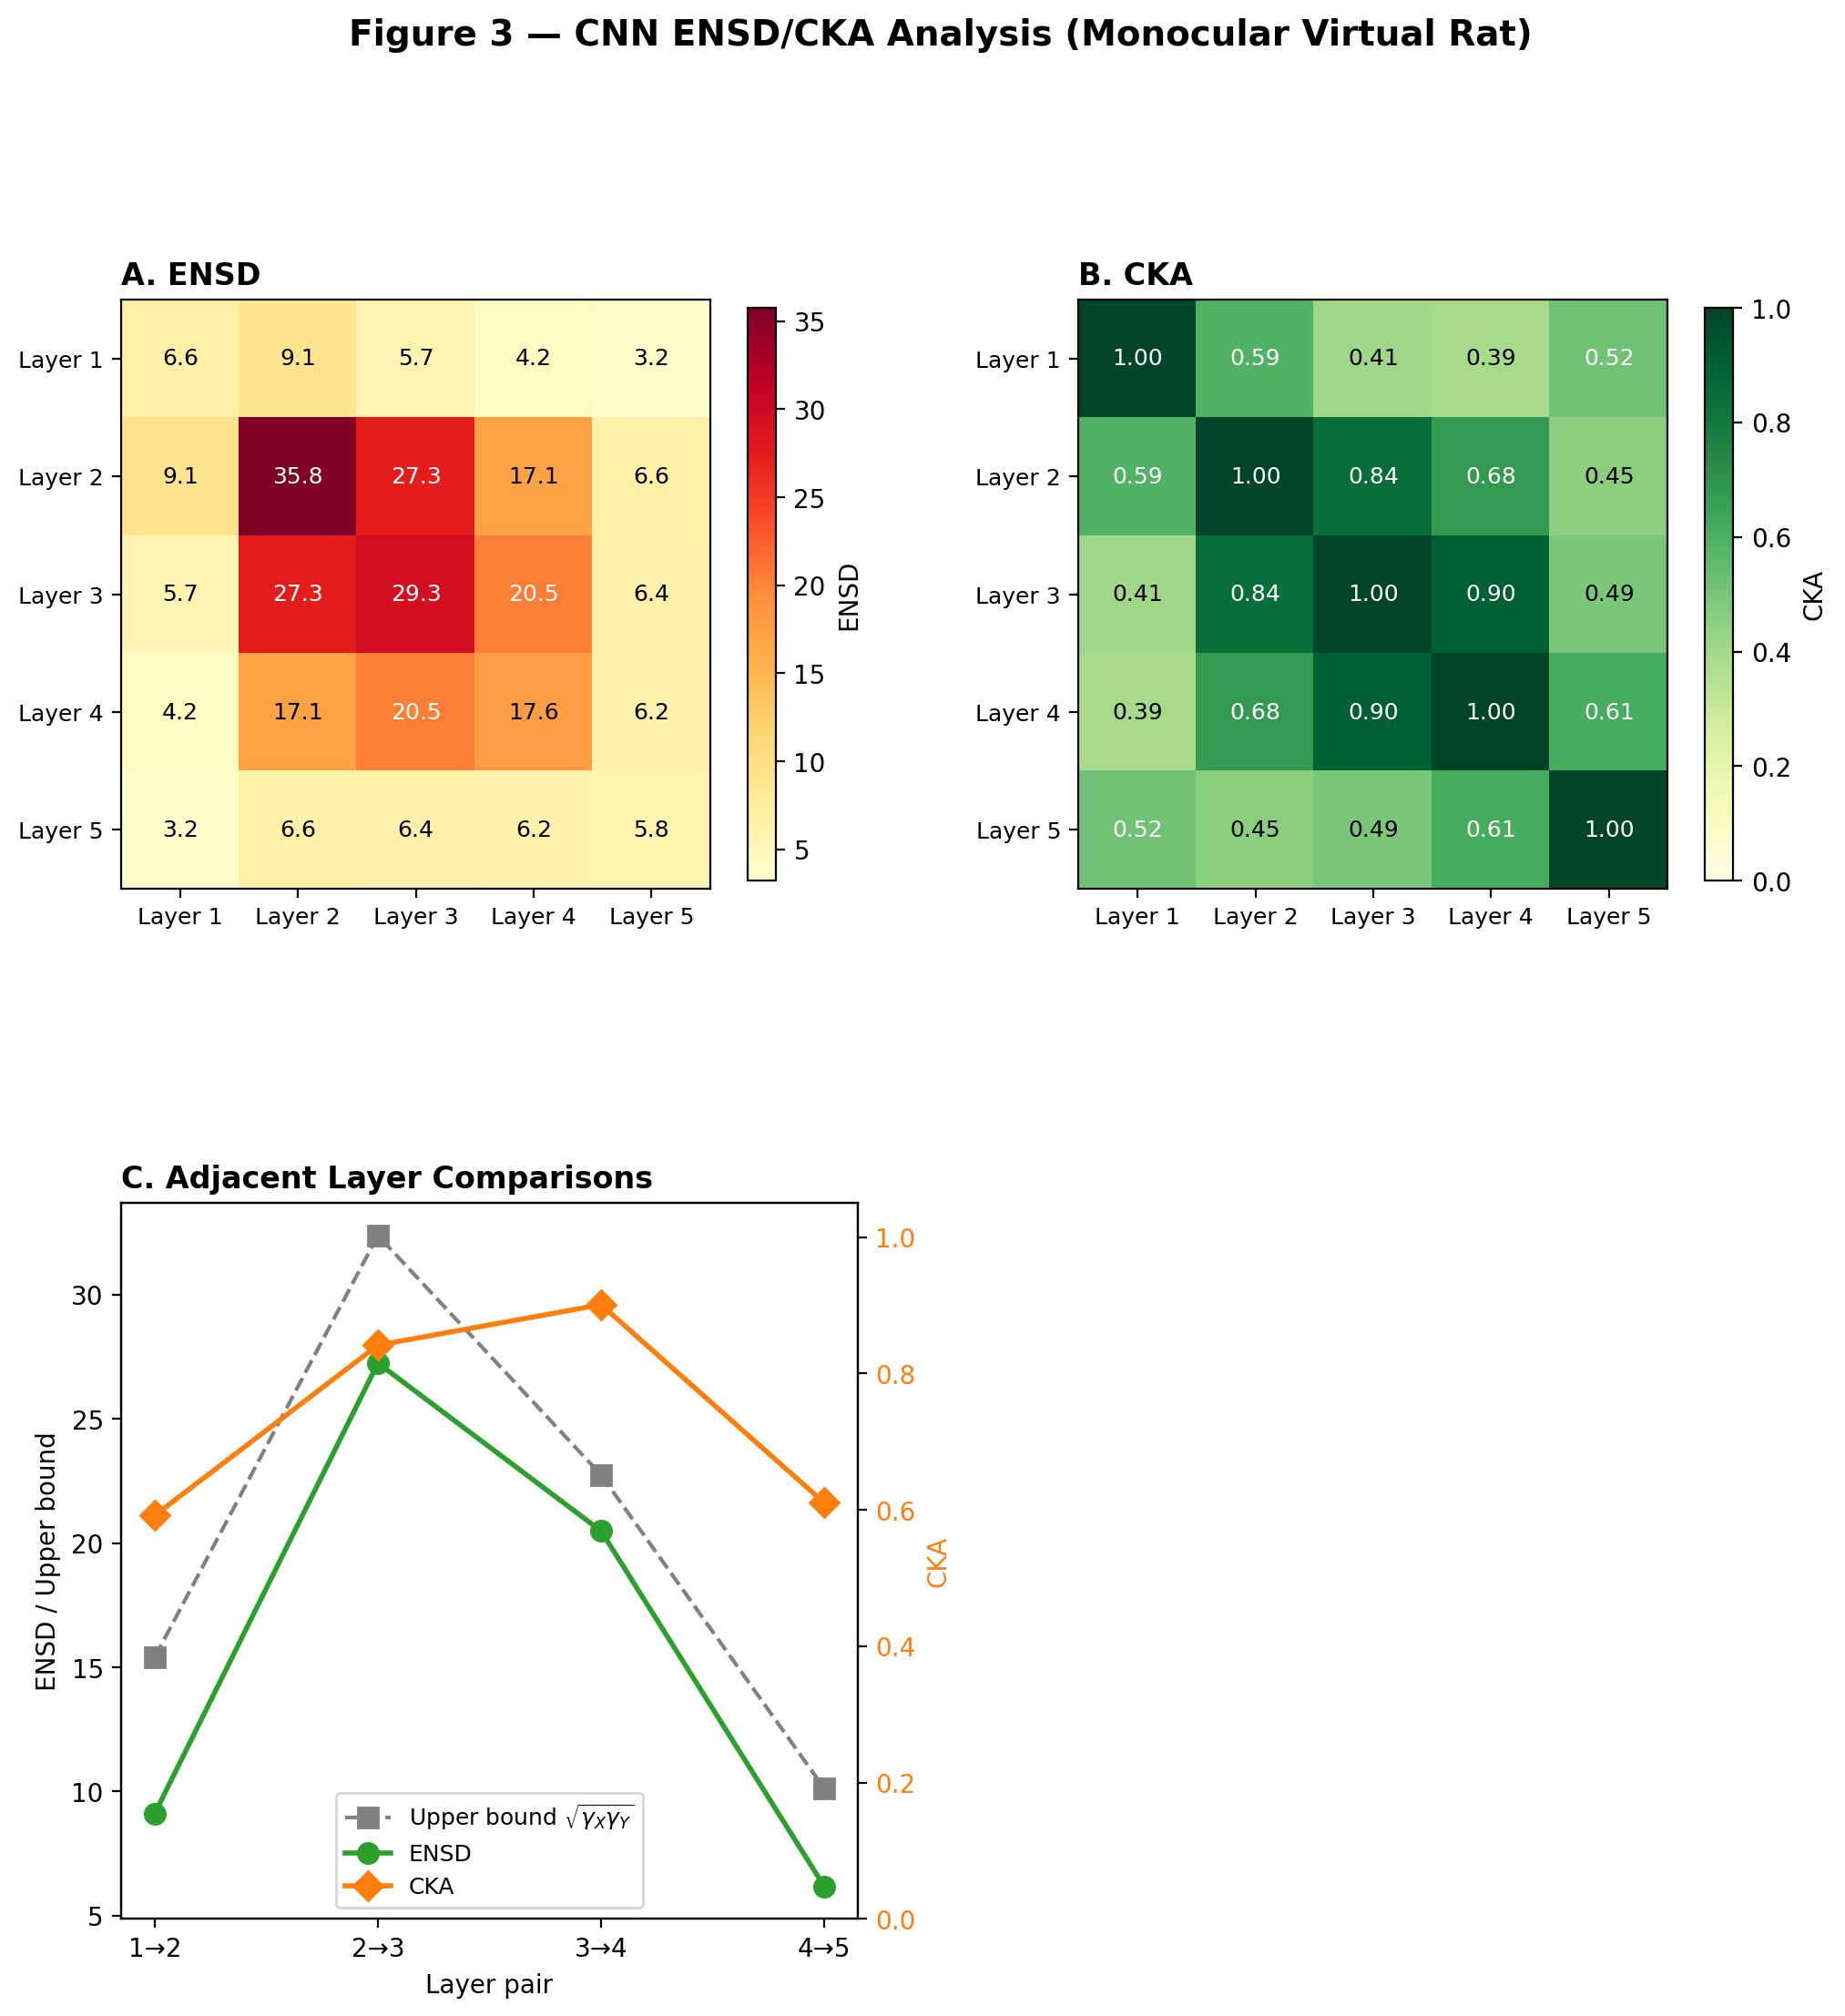

In [21]:
%config InlineBackend.figure_format = "retina"

cnn_layers = ["conv0", "conv1", "conv2", "conv3", "cnn_features"]
cnn_layers = [l for l in cnn_layers if l in layer_matrices]
n_cnn = len(cnn_layers)

cnn_ensd = np.zeros((n_cnn, n_cnn))
cnn_cka = np.zeros((n_cnn, n_cnn))
cnn_pr = {}

for i, l1 in enumerate(cnn_layers):
    cnn_pr[l1] = participation_ratio(layer_matrices[l1])
    for j, l2 in enumerate(cnn_layers):
        if i == j:
            cnn_ensd[i, j] = cnn_pr[l1]
            cnn_cka[i, j] = 1.0
        elif j > i:
            cnn_ensd[i, j] = cnn_ensd[j, i] = ensd(
                layer_matrices[l1], layer_matrices[l2]
            )
            cnn_cka[i, j] = cnn_cka[j, i] = cka(
                layer_matrices[l1], layer_matrices[l2]
            )

# ── Figure 3 reproduction (ENSD + CKA + adjacent summary) ──
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], wspace=0.3, hspace=0.35)

layer_labels = [f"Layer {i+1}" for i in range(n_cnn)]

# 3A: ENSD heatmap
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(cnn_ensd, cmap="YlOrRd")
ax1.set_xticks(range(n_cnn))
ax1.set_xticklabels(layer_labels, fontsize=9)
ax1.set_yticks(range(n_cnn))
ax1.set_yticklabels(layer_labels, fontsize=9)
ax1.set_title("A. ENSD", fontsize=12, fontweight="bold", loc="left")
plt.colorbar(im1, ax=ax1, shrink=0.8, label="ENSD")
for i in range(n_cnn):
    for j in range(n_cnn):
        color = "white" if cnn_ensd[i, j] > cnn_ensd.max() * 0.5 else "black"
        ax1.text(
            j, i, f"{cnn_ensd[i, j]:.1f}",
            ha="center", va="center", fontsize=9, color=color,
        )

# 3B: CKA heatmap
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(cnn_cka, cmap="YlGn", vmin=0, vmax=1)
ax2.set_xticks(range(n_cnn))
ax2.set_xticklabels(layer_labels, fontsize=9)
ax2.set_yticks(range(n_cnn))
ax2.set_yticklabels(layer_labels, fontsize=9)
ax2.set_title("B. CKA", fontsize=12, fontweight="bold", loc="left")
plt.colorbar(im2, ax=ax2, shrink=0.8, label="CKA")
for i in range(n_cnn):
    for j in range(n_cnn):
        color = "white" if cnn_cka[i, j] > 0.5 else "black"
        ax2.text(
            j, i, f"{cnn_cka[i, j]:.2f}",
            ha="center", va="center", fontsize=9, color=color,
        )

# 3C: Adjacent layer summary (square, single column)
ax3 = fig.add_subplot(gs[1, 0])
adj_e = [cnn_ensd[i, i + 1] for i in range(n_cnn - 1)]
adj_u = [
    np.sqrt(cnn_pr[cnn_layers[i]] * cnn_pr[cnn_layers[i + 1]])
    for i in range(n_cnn - 1)
]
adj_c = [cnn_cka[i, i + 1] for i in range(n_cnn - 1)]
adj_lbl = [f"{i+1}\u2192{i+2}" for i in range(n_cnn - 1)]

ax3.plot(adj_u, "s--", color="gray", label=r"Upper bound $\sqrt{\gamma_X \gamma_Y}$", linewidth=1.5, markersize=8)
ax3.plot(adj_e, "o-", color="tab:green", label="ENSD", linewidth=2, markersize=8)
ax3.set_xticks(range(len(adj_lbl)))
ax3.set_xticklabels(adj_lbl, fontsize=10)
ax3.set_xlabel("Layer pair")
ax3.set_ylabel("ENSD / Upper bound")
ax3.set_title("C. Adjacent Layer Comparisons", fontsize=12, fontweight="bold", loc="left")

ax3_twin = ax3.twinx()
ax3_twin.plot(adj_c, "D-", color="tab:orange", label="CKA", linewidth=2, markersize=8)
ax3_twin.set_ylabel("CKA", color="tab:orange")
ax3_twin.tick_params(axis="y", labelcolor="tab:orange")
ax3_twin.set_ylim(0, 1.05)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc="lower center", fontsize=9)

model_label = "Binocular" if is_binocular else "Monocular"
fig.suptitle(
    f"Figure 3 — CNN ENSD/CKA Analysis ({model_label} Virtual Rat)",
    fontsize=14, fontweight="bold",
)
fig.tight_layout()
plt.savefig(
    str(CHECKPOINT_DIR.parent / "figure3_reproduction.png"),
    dpi=200, bbox_inches="tight",
)
plt.show()

## 12. Eigenspectrum Analysis

Eigenvalue distributions for each CNN layer. Flat eigenspectra (uniform variance across PCs)
correspond to high PR; concentrated eigenspectra (variance dominated by few PCs) correspond to low PR.

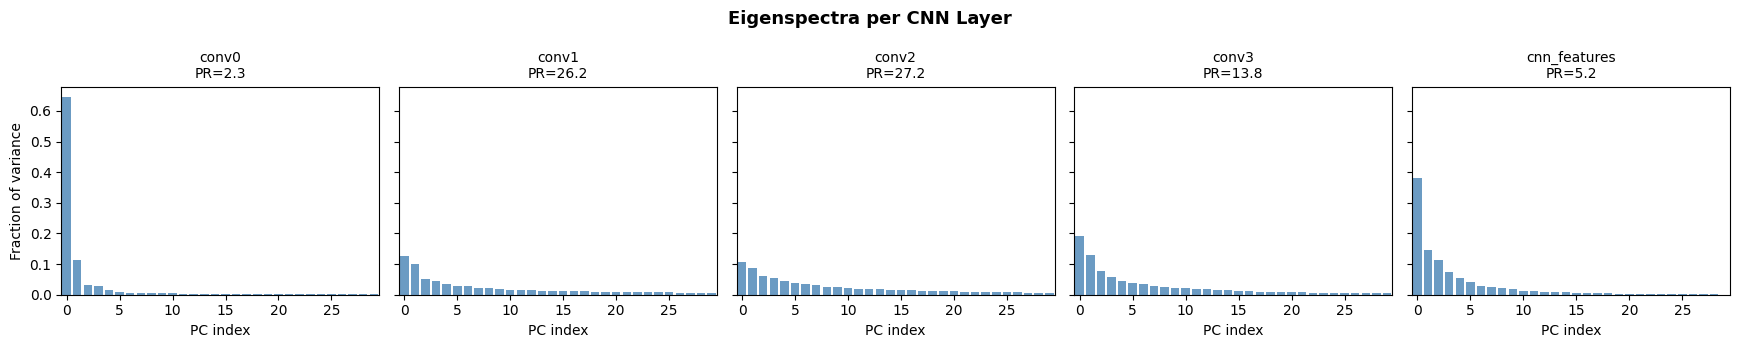

In [15]:
fig, axes = plt.subplots(1, len(cnn_layers), figsize=(3.5 * len(cnn_layers), 3.5), sharey=True)

for idx, layer_name in enumerate(cnn_layers):
    X = layer_matrices[layer_name]
    X = X - X.mean(axis=0, keepdims=True)
    cov = X.T @ X / X.shape[0]
    eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]
    eigvals_norm = eigvals / eigvals.sum() if eigvals.sum() > 0 else eigvals

    ax = axes[idx]
    n_show = min(30, len(eigvals_norm))
    ax.bar(range(n_show), eigvals_norm[:n_show], color="steelblue", alpha=0.8)
    ax.set_title(f"{layer_name}\nPR={cnn_pr[layer_name]:.1f}", fontsize=10)
    ax.set_xlabel("PC index")
    if idx == 0:
        ax.set_ylabel("Fraction of variance")
    ax.set_xlim(-0.5, n_show - 0.5)

fig.suptitle("Eigenspectra per CNN Layer", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig(
    str(CHECKPOINT_DIR.parent / "eigenspectra.png"),
    dpi=150, bbox_inches="tight",
)
plt.show()

## 13. ENSD Decomposition (Λ and W matrices)

The ENSD can be decomposed as $\tau_{X,Y} = \boldsymbol{\lambda}_X^\top \mathbf{W} \boldsymbol{\lambda}_Y$ where:
- **Λ** = outer product of normalized eigenvalues (eigenspectrum similarity)
- **W** = squared eigenvector overlaps (subspace alignment)

This shows *how* the shared structure is organized: whether it's concentrated in a
few dimensions (block-diagonal W) or spread across many (diffuse W).

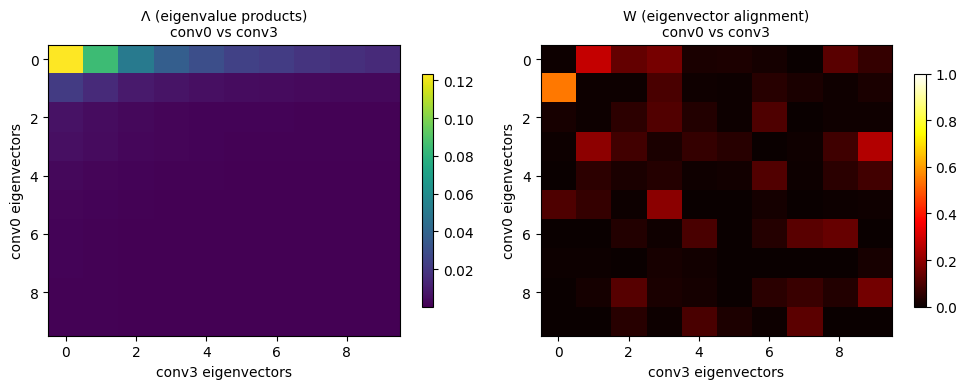

In [16]:
def ensd_decomposition(X, Y, k=10):
    """Decompose ENSD into eigenvalue (Λ) and eigenvector alignment (W) components.

    Uses Gram matrix (XX^T, YY^T) eigenvectors which live in sample space
    (both n×n), so W is well-defined even when X and Y have different feature dims.
    """
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)

    # Gram matrices (n × n) — same size regardless of feature dims
    Gx = X @ X.T
    Gy = Y @ Y.T

    eigvals_x, eigvecs_x = np.linalg.eigh(Gx)
    eigvals_y, eigvecs_y = np.linalg.eigh(Gy)

    # Sort descending
    idx_x = np.argsort(eigvals_x)[::-1]
    idx_y = np.argsort(eigvals_y)[::-1]
    eigvals_x = eigvals_x[idx_x]
    eigvecs_x = eigvecs_x[:, idx_x]
    eigvals_y = eigvals_y[idx_y]
    eigvecs_y = eigvecs_y[:, idx_y]

    # Normalize eigenvalues
    lam_x = eigvals_x / eigvals_x.sum() if eigvals_x.sum() > 0 else eigvals_x
    lam_y = eigvals_y / eigvals_y.sum() if eigvals_y.sum() > 0 else eigvals_y

    k = min(k, len(lam_x), len(lam_y))
    lambda_mat = np.outer(lam_x[:k], lam_y[:k])
    W = (eigvecs_x[:, :k].T @ eigvecs_y[:, :k]) ** 2

    return lambda_mat, W


# Show for conv0 vs conv3
pair_1, pair_2 = "conv0", "conv3"
if pair_1 in layer_matrices and pair_2 in layer_matrices:
    lam, W = ensd_decomposition(layer_matrices[pair_1], layer_matrices[pair_2])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    im1 = ax1.imshow(lam, cmap="viridis", aspect="auto")
    ax1.set_title(f"Λ (eigenvalue products)\n{pair_1} vs {pair_2}", fontsize=10)
    ax1.set_xlabel(f"{pair_2} eigenvectors")
    ax1.set_ylabel(f"{pair_1} eigenvectors")
    plt.colorbar(im1, ax=ax1, shrink=0.8)

    im2 = ax2.imshow(W, cmap="hot", vmin=0, vmax=1, aspect="auto")
    ax2.set_title(f"W (eigenvector alignment)\n{pair_1} vs {pair_2}", fontsize=10)
    ax2.set_xlabel(f"{pair_2} eigenvectors")
    ax2.set_ylabel(f"{pair_1} eigenvectors")
    plt.colorbar(im2, ax=ax2, shrink=0.8)

    fig.tight_layout()
    plt.show()

## 14. Export Results

Save the computed metrics for later comparison (e.g., binocular vs monocular).

In [17]:
results = {
    "checkpoint": str(CHECKPOINT_DIR),
    "is_binocular": is_binocular,
    "analysis_layers": analysis_layers,
    "pr_values": {k: float(v) for k, v in pr_values.items()},
    "ensd_matrix": ensd_matrix.tolist(),
    "cka_matrix": cka_matrix.tolist(),
    "layer_shapes": {k: list(v.shape) for k, v in layer_matrices.items()},
}

results_path = CHECKPOINT_DIR / "ensd_cka_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved to {results_path}")

Results saved to /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/260215_091930/ensd_cka_results.json
